In [1]:
import torch
import dnnlib
import legacy
import math
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import json
from sklearn.decomposition import PCA
import clip
import copy

In [2]:
def plot_tensor_images(images, titles=None, cols=4, figsize=4):
    if not isinstance(images, list):
        images = [images]

    n = len(images)
    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols * figsize, rows * figsize))

    for i, img in enumerate(images):
        img = (img.permute(0, 2, 3, 1) * 127.5 + 128).clamp(0, 255).to(torch.uint8)
        pil_img = Image.fromarray(img[0].cpu().numpy())
        plt.subplot(rows, cols, i + 1)
        plt.imshow(pil_img)
        plt.axis("off")

        if titles and i < len(titles):
            plt.title(titles[i], fontsize=10)

    plt.tight_layout()
    plt.show()

In [3]:
network_pkl = "ffhq.pkl"
device = torch.device("cuda")
with dnnlib.util.open_url(network_pkl) as f:
    G = legacy.load_network_pkl(f)["G_ema"].to(device)

In [ ]:
print(G)

In [4]:
affines = []

for name, module in G.synthesis.named_modules():
    if hasattr(module, "affine"):
        affines.append(module.affine)
# print(len(affines))
# print(affines)

mapping = G.mapping

In [5]:
class StyleAffineMapper(torch.nn.Module):
    def __init__(self, mapping, affines):
        super().__init__()
        self.mapping = mapping
        self.affines = torch.nn.ModuleList(affines)

    def forward(self, z, truncation=0.5):
        w = self.mapping(z, None, truncation_psi=truncation)  # shape [batch, 14, 512]

        outputs = []

        # Handle First Block
        outputs.append(self.affines[0](w[:, 0]))  # conv1
        outputs.append(self.affines[1](w[:, 1]))  # toRGB

        # Rest of the blocks
        w_idx = 2
        affine_idx = 2
        for _ in range(8):
            # conv0
            outputs.append(self.affines[affine_idx](w[:, w_idx]))
            # conv1
            outputs.append(self.affines[affine_idx + 1](w[:, w_idx + 1]))
            # toRGB (reuses the second w vector of this block)
            outputs.append(self.affines[affine_idx + 2](w[:, w_idx + 1]))

            w_idx += 2
            affine_idx += 3

        return outputs

In [6]:
class StyleSynthesisNetwork(torch.nn.Module):
    def __init__(self, synthesis):
        super().__init__()
        self.synthesis = synthesis
        
        for name, module in self.synthesis.named_modules():
            if hasattr(module, 'affine'):
                module.affine = torch.nn.Identity()

    def forward(self, precomputed_styles):

        style_idx = 0
        
        def hooked_forward(module, input):
            nonlocal style_idx
            new_input = list(input)
            new_input[1] = precomputed_styles[style_idx]
            style_idx += 1
            return tuple(new_input)

        hooks = []
        for name, module in self.synthesis.named_modules():
            if hasattr(module, 'affine'):
                hooks.append(module.register_forward_pre_hook(hooked_forward)) # pre-hook to replace the style input with precomputed styles

        try:
            dummy_ws = torch.zeros(precomputed_styles[0].shape[0],
                                   self.synthesis.num_ws, 512).to(precomputed_styles[0].device) # use a dummy tensor since styles are loaded via hooks
            img = self.synthesis(dummy_ws)
        finally:
            for h in hooks:
                h.remove()
                
        return img

Style vector 1: shape torch.Size([1, 512])
Style vector 2: shape torch.Size([1, 512])
Style vector 3: shape torch.Size([1, 512])
Style vector 4: shape torch.Size([1, 512])
Style vector 5: shape torch.Size([1, 512])
Style vector 6: shape torch.Size([1, 512])
Style vector 7: shape torch.Size([1, 512])
Style vector 8: shape torch.Size([1, 512])
Style vector 9: shape torch.Size([1, 512])
Style vector 10: shape torch.Size([1, 512])
Style vector 11: shape torch.Size([1, 512])
Style vector 12: shape torch.Size([1, 512])
Style vector 13: shape torch.Size([1, 512])
Style vector 14: shape torch.Size([1, 512])
Style vector 15: shape torch.Size([1, 512])
Style vector 16: shape torch.Size([1, 256])
Style vector 17: shape torch.Size([1, 256])
Style vector 18: shape torch.Size([1, 256])
Style vector 19: shape torch.Size([1, 128])
Style vector 20: shape torch.Size([1, 128])
Style vector 21: shape torch.Size([1, 128])
Style vector 22: shape torch.Size([1, 64])
Style vector 23: shape torch.Size([1, 64])

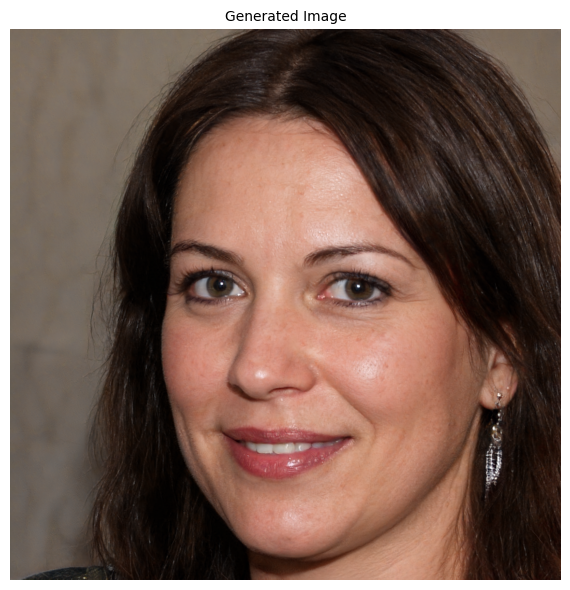

In [9]:
style_generator = StyleAffineMapper(mapping, affines)
style_synthesis = StyleSynthesisNetwork(G.synthesis)

z = torch.randn(1, 512).to(device)
styles = style_generator(z, truncation=0.5)
for i, style_vector in enumerate(styles):
    print(f"Style vector {i+1}: shape {style_vector.shape}")
generated_image = style_synthesis(styles)
print(generated_image.shape)
plot_tensor_images(generated_image, titles=["Generated Image"], cols=1, figsize=6)

In [10]:
with open('clip_data/imagenet_templates.json', 'r') as f:
    data = json.load(f)
    imagenet_templates = data['imagenet_templates']
    
def zeroshot_classifier(classnames, templates,model):
    '''get the CLIP text embedding for the given classnames'''
    with torch.no_grad():
        zeroshot_weights = []
        for classname in classnames:
            texts = [template.format(classname) for template in templates] # format the text(classname) with  templates to get average text embedding, which is more robust to different templates.
            texts = clip.tokenize(texts).cuda() #tokenize
            class_embeddings = model.encode_text(texts) #embed with text encoder
            class_embeddings /= class_embeddings.norm(dim=-1, keepdim=True)
            class_embedding = class_embeddings.mean(dim=0)
            class_embedding /= class_embedding.norm()
            zeroshot_weights.append(class_embedding)
        zeroshot_weights = torch.stack(zeroshot_weights, dim=1).cuda()
    return zeroshot_weights

def GetClipDirection(classnames,model):
    '''get the CLIP direction vector for the target - neutral class clip embeddings'''
    text_features=zeroshot_classifier(classnames, imagenet_templates,model).t()
    
    dt=text_features[0]-text_features[1]
    dt=dt.cpu().numpy()
    

    print(np.linalg.norm(dt))
    dt=dt/np.linalg.norm(dt)
    return dt

In [11]:
def SplitS(style_direction_flattened):
    start=0
    style_direction=[]

    mindexs = [0, 2, 3, 5, 6, 8, 9, 11, 12, 14, 15, 17, 18, 20, 21, 23, 24] # ingoring ToRGB layers
    style_shapes = [512] * 15 + [256] * 3 + [128] * 3 + [64] * 3 + [32] * 2
    
    for i in range(26):
        if i in mindexs:
            layer_len=style_shapes[i]
            end=start+layer_len
            style=style_direction_flattened[start:end]
            start=end
        else:
            style=np.zeros(style_shapes[i])
        style = torch.tensor(style)
        style_2d = style.unsqueeze(0)

        style_direction.append(style_2d.detach().clone().float().cuda())
    return style_direction

def GetStyleDirection(clip2styles_matrix,clip_direction,threshold):
    '''get the direction in the style space (boundary) with the precomputed clip2styles matrix.'''
    style_direction_flattened=np.dot(clip2styles_matrix,clip_direction) # project the CLIP direction to the style space with the precomputed clip2styles matrix, which is trained to map CLIP directions to style space directions.
    
    style_direction_flattened_2=copy.copy(style_direction_flattened)
    select=np.abs(style_direction_flattened)<threshold
    num_c=np.sum(~select)


    style_direction_flattened_2[select]=0 # apply threshold
    tmp=np.abs(style_direction_flattened_2).max()
    print('max value before normalization:',tmp)
    style_direction_flattened_2/= (tmp + 1e-5) # normalize
    
    style_direction=SplitS(style_direction_flattened_2) # split flattend style vector into different layers
    print('num of channels being manipulated:',num_c)
    return style_direction,num_c

def GetStyleDirectionModel(clip2styles_matrix,clip_direction,threshold,clip2styles_model):
    '''get the direction in the style space (boundary) with the precomputed clip2styles matrix.'''
    style_direction_flattened = clip2styles_model(torch.tensor(clip_direction).float().cuda()) # project the CLIP direction to the style space with the precomputed clip2styles matrix, which is trained to map CLIP directions to style space directions.
    style_direction_flattened=style_direction_flattened.cpu().detach().numpy()
    style_direction_flattened_2=copy.copy(style_direction_flattened)
    select=np.abs(style_direction_flattened)<threshold
    num_c=np.sum(~select)


    style_direction_flattened_2[select]=0 # apply threshold
    tmp=np.abs(style_direction_flattened_2).max()
    print('max value before normalization:',tmp)
    style_direction_flattened_2/= (tmp + 1e-5) # normalize
    
    style_direction=SplitS(style_direction_flattened_2) # split flattend style vector into different layers
    print('num of channels being manipulated:',num_c)
    return style_direction,num_c

In [12]:
def CalcStyleVectors(style_vecs_initial, style_direction, alpha = 1): # 26, 512 || 
    '''Manipulate the style vectors by adding the boundary direction, and return the manipulated style vectors as a list'''
    style_vecs_manipulated= copy.deepcopy(style_vecs_initial)
    l=torch.tensor([[alpha]]).float().to(device) # manipulation strength for each step, shape = step

    assert len(style_vecs_manipulated) == len(style_direction)
    for i in range(len(style_direction)): # for each layer
        style_vecs_manipulated[i]+=l*style_direction[i] # manipulate the style vectors in the direction of style_direction with strength l
    
    return style_vecs_manipulated

# Define Clip2Style Mapper
Only run one of the cells.

In [ ]:
class Clip2StyleMapper(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(512, 1024),
            torch.nn.ReLU(),
            torch.nn.Linear(1024, 2048),
            torch.nn.ReLU(),
            torch.nn.Linear(2048, 6048)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class Clip2StyleMapper(torch.nn.Module):
    def __init__(self):
        super().__init__()       
        self.net = torch.nn.Sequential(torch.nn.Linear(512, 6048))

    def forward(self, x):
        return self.net(x)

# Generate inital style vectors

In [19]:
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)

clip2styles_matrix = np.load("clip_data/clip2styles.npy")

z = torch.randn(1, 512).to(device)
style_vecs_initial = style_generator(z, truncation=0.5)

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
C:\Users\kbras\AppData\Local\Temp\ipykernel_2908\3910581596.py:11: SyntaxWarning: invalid escape sequence '\m'
  clip2styles_mapper.load_state_dict(torch.load('out\mapping_network_2layer_1stage_linear_2.pth'))



white_hair 0.15 4.0
0.4272
max value before normalization: 0.4639404
num of channels being manipulated: 59


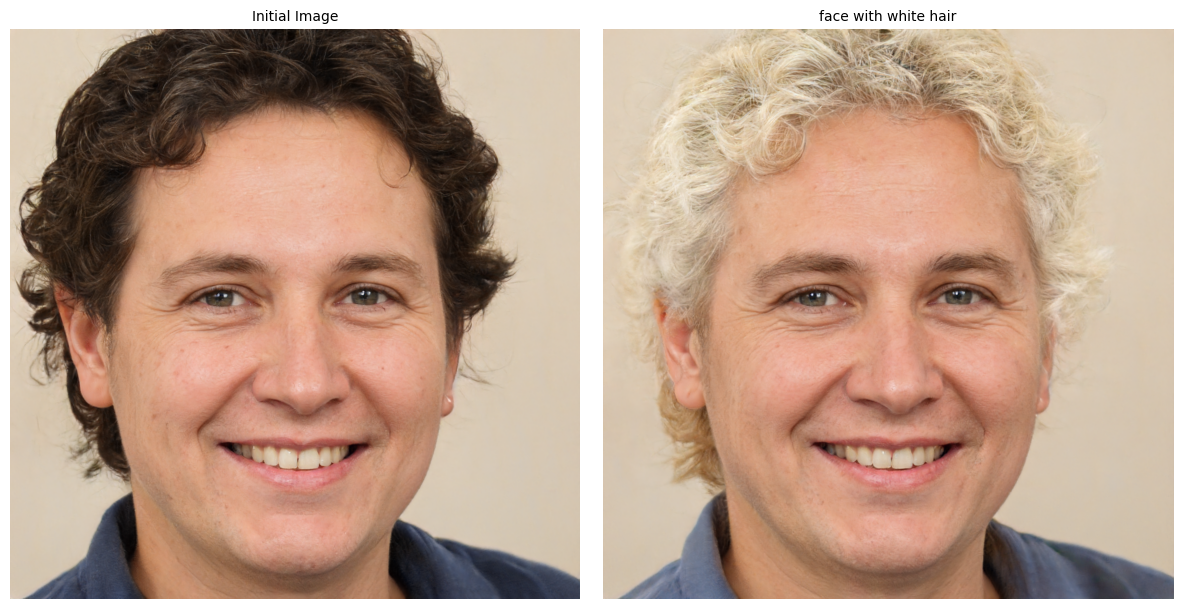

In [ ]:
prompts = np.array(
    [
        # ["original", "person", "original", 0, 0],
        ["white_hair", "face with black hair", "face with white hair", 0.15, 4],
        # ["dark_skin", "face with white skin", "face with black skin", 0.15, 10],
        # ["with_beared", "face without beared", "face with beared", 0.15, 4],
    ]
)

clip2styles_mapper = Clip2StyleMapper().to(device)
clip2styles_mapper.load_state_dict(torch.load('out\mapping_network_2layer_1stage_linear_2.pth'))

def ManipulateImages(classnames, model, clip2styles_matrix, style_vecs_initial, beta, alpha):
    clip_direction = GetClipDirection(
        classnames, model
    )  # Get the CLIP direction vector for the target - neutral classes

    style_direction, num_c = GetStyleDirectionModel(clip2styles_matrix, clip_direction, threshold=beta, clip2styles_model=clip2styles_mapper) # Get the style space direction corresponding to the CLIP direction

    style_vecs_manipulated = CalcStyleVectors(style_vecs_initial, style_direction, alpha) # Manipulate the style vectors in the direction of the style_direction with the given alpha and beta | shape = layers, num_images, steps,  feature_dimensions

    return style_vecs_manipulated


for i in range(len(prompts)): # for each text prompt
    filename, neutral, target, beta, alpha = prompts[i]

    beta = np.float32(beta)
    alpha = np.float32(alpha)

    print()
    print(filename, beta, alpha)
    classnames = [target, neutral]

    style_vecs_manipulated = ManipulateImages(classnames, model, clip2styles_matrix, style_vecs_initial, beta, alpha)

    # Generate images and plot
    generated_image_initial = style_synthesis(style_vecs_initial)
    generated_image_manipulated = style_synthesis(style_vecs_manipulated)
    combined = [generated_image_initial, generated_image_manipulated]
    plot_tensor_images(combined, titles=["Initial Image", target], cols=2, figsize=6)

0.4783
max value before normalization: 0.3304512
num of channels being manipulated: 165
Prompt:  male face with blue eyes.


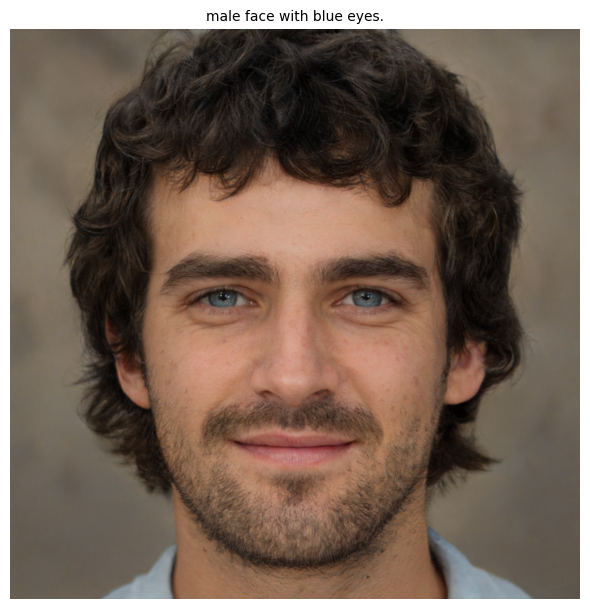

In [102]:
z = torch.zeros(1, 512).to(device)
style_vecs_avg = style_generator(z, truncation=0.5)

filename = "init"
neutral = "female face with eyes"

image_prompt = "male face with blue eyes."
beta, alpha = 0.15, 3

style_vecs_start = ManipulateImages([image_prompt, neutral], model, clip2styles_matrix, style_vecs_avg, beta, alpha)
generated_image_start = style_synthesis(style_vecs_start)

print("Prompt: ",image_prompt)
plot_tensor_images(generated_image_start, titles=[image_prompt], cols=2, figsize=6)